# **IMBALANCE ANALYSIS AND MITIGATION**

## **IMPORTS**

In [7]:
# General imports
import pandas as pd
import numpy as np
from imblearn.pipeline import make_pipeline as imb_make_pipeline
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, cohen_kappa_score

# Preprocessor imports
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from preprocessing.preprocessor import preprocessorLOEEALL

# Oversampling imports
from imblearn.over_sampling import SMOTE, RandomOverSampler, ADASYN, BorderlineSMOTE

# Undersampling imports
from imblearn.under_sampling import RandomUnderSampler, EditedNearestNeighbours, NearMiss, TomekLinks

# Combination imports
from imblearn.combine import SMOTEENN, SMOTETomek

# Model imports
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier
import xgboost as xgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

## **DATASET LOADING**

In [8]:
# We read the partitions
X_train = pd.read_parquet("../data/cleaned/X_train.parquet")
X_test = pd.read_parquet("../data/cleaned/X_test.parquet")
y_train = pd.read_parquet("../data/cleaned/y_train.parquet").squeeze()
y_test = pd.read_parquet("../data/cleaned/y_test.parquet").squeeze()

# Check that all has been loaded correctly
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

categorical_cols = ['Type', 'Gender', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'RescuerID', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength','Breed1', 'Breed2', 'State']

(10045, 32)
(10045,)
(4948, 32)
(4948,)


## **MODELS & TECHNIQUES**

### Models

In [12]:
# MODELS: default hyperparameters, random_state=42
MODELS = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Bagging': BaggingClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0, allow_writing_files=False)
}

### Balanced models

In [13]:
# MODELS_BALANCED: same models, class_weight='balanced' (where possible)
MODELS_BALANCED = {
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'AdaBoost': AdaBoostClassifier(random_state=42),  # doesn't have class_weight
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),  # doesn't have class_weight 
    'Bagging': BaggingClassifier(random_state=42),  # doesn't have class_weight 
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),  # doesn't have class_weight
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced'),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0, auto_class_weights='Balanced', allow_writing_files=False),
    'CatBoost_native_categorical': CatBoostClassifier(random_state=42, verbose=0, allow_writing_files=False, cat_features=categorical_cols),
    'CatBoost_native_categorical_balanced': CatBoostClassifier(random_state=42, verbose=0, allow_writing_files=False, auto_class_weights='Balanced', cat_features=categorical_cols)
}

### Balancing techniques

In [ ]:
# BALANCING_TECHNIQUES: techniques to mitigate the class imbalance
BALANCING_TECHNIQUES = {
    'None': 'passthrough',  # to compare without resampling
    'SMOTE (oversampling)': SMOTE(random_state=42),
    'RandomOverSampler (oversampling)': RandomOverSampler(random_state=42),
    'ADASYN (oversampling)': ADASYN(random_state=42, sampling_strategy='minority'),
    'BorderlineSMOTE (oversampling)': BorderlineSMOTE(random_state=42),
    'RandomUnderSampler (undersampling)': RandomUnderSampler(random_state=42),
    'EditedNearestNeighbours (undersampling)': EditedNearestNeighbours(), #Deterministic
    'NearMiss (undersampling)': NearMiss(), #Deterministic
    'TomekLinks (undersampling)': TomekLinks(), #Deterministic
    'SMOTEENN (combination)': SMOTEENN(random_state=42),
    'SMOTETomek (combination)': SMOTETomek(random_state=42)
}

### Initialization

In [9]:
# Initializing the folds that we will be using
skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

# Initializng the second evaluation technique
qwk = make_scorer(cohen_kappa_score, weights="quadratic")
scoring = {
    "f1_macro": "f1_macro",
    "balanced_acc": "balanced_accuracy",
    "mcc": "matthews_corrcoef",
    "QWK": qwk
}

# Initializing the results
results = []

## **IMBALANCE ANALYSIS**

Class 4: 
        Amount train: 2812 --> 27.99%
        Amount test: 1385 --> 27.99%
        Total: 4197 --> 27.99%
Class 2: 
        Amount train: 2705 --> 26.93%
        Amount test: 1332 --> 26.92%
        Total: 4037 --> 26.93%
Class 3: 
        Amount train: 2183 --> 21.73%
        Amount test: 1076 --> 21.75%
        Total: 3259 --> 21.74%
Class 1: 
        Amount train: 2070 --> 20.61%
        Amount test: 1020 --> 20.61%
        Total: 3090 --> 20.61%
Class 0: 
        Amount train: 275 --> 2.74%
        Amount test: 135 --> 2.73%
        Total: 410 --> 2.73%


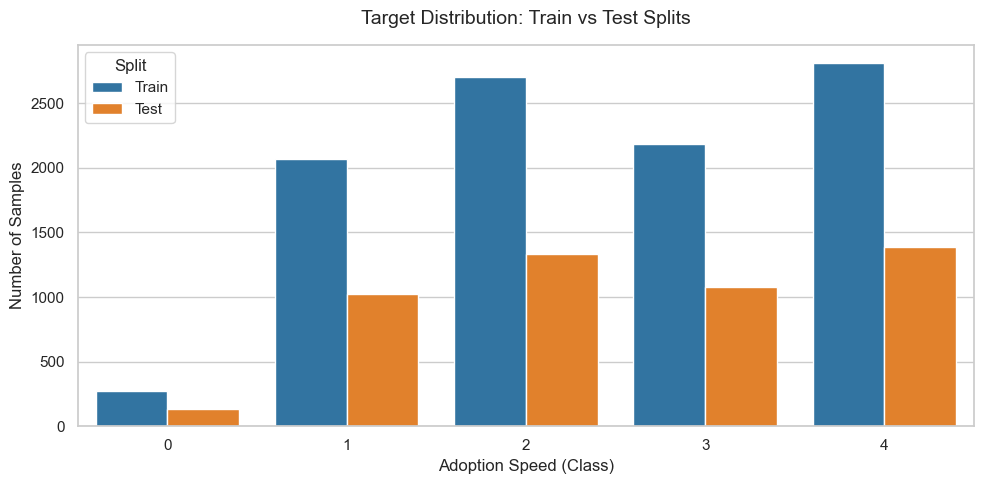


--- Imbalance Analysis Metrics ---
Majority class count: 2812
Minority class count: 275
Imbalance Ratio (IR): 10.23:1


In [11]:
target_distribution_train = y_train.value_counts()
target_distribution_test = y_test.value_counts()


for key, amount_train, amount_test in zip(target_distribution_train.index, target_distribution_train.values, target_distribution_test):
    print(f"""Class {key}: 
        Amount train: {amount_train} --> {round((amount_train/y_train.shape[0])*100, 2)}%
        Amount test: {amount_test} --> {round((amount_test/y_test.shape[0])*100, 2)}%
        Total: {amount_train+amount_test} --> {round((((amount_train+amount_test)/(y_train.shape[0]+y_test.shape[0])))*100, 2)}%""")
        
    
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Preparar los datos en un DataFrame para facilitar el ploteo
target_train_df = pd.DataFrame({'Class': target_distribution_train.index, 'Count': target_distribution_train.values, 'Set': 'Train'})
target_test_df = pd.DataFrame({'Class': target_distribution_test.index, 'Count': target_distribution_test.values, 'Set': 'Test'})
df_dist = pd.concat([target_train_df, target_test_df])

# 2. Gráfico: Distribución Train vs Test
plt.figure(figsize=(10, 5))
sns.barplot(data=df_dist, x='Class', y='Count', hue='Set', palette=['#1f77b4', '#ff7f0e'])
plt.title('Target Distribution: Train vs Test Splits', fontsize=14, pad=15)
plt.ylabel('Number of Samples')
plt.xlabel('Adoption Speed (Class)')
plt.legend(title='Split')
plt.tight_layout()
plt.show()

# 3. Cálculo de la Métrica Académica: Imbalance Ratio (IR)
majority_class_train = target_distribution_train.max()
minority_class_train = target_distribution_train.min()
imbalance_ratio = majority_class_train / minority_class_train

print("\n--- Imbalance Analysis Metrics ---")
print(f"Majority class count: {majority_class_train}")
print(f"Minority class count: {minority_class_train}")
print(f"Imbalance Ratio (IR): {round(imbalance_ratio, 2)}:1")


## **IMBALANCE MITIGATION**

### Base models

In [ ]:
# First we execute the base models

for model_name, model in MODELS_BALANCED.items():

    if model_name != "CatBoost_native_categorical" and model_name != "CatBoost_native_categorical_balanced":
        pipe = imb_make_pipeline(preprocessorLOEEALL, model)
    else:
        pipe = imb_make_pipeline(model)

    results_cv = cross_validate(pipe, X_train, y_train, cv=skf, scoring=scoring, n_jobs=-1, return_train_score=True)

    result = {
        "Model": f"{model_name} balanced",
        "balancing_technique": "no",

        # F1 Macro
        "f1_mean_test": np.mean(results_cv["test_f1_macro"]),
        "f1_mean_train": np.mean(results_cv["train_f1_macro"]),
        "f1_sd_test": np.std(results_cv["test_f1_macro"]),
        "f1_sd_train": np.std(results_cv["train_f1_macro"]),

        # QWK (Quadratic Weighted Kappa)
        "qwk_mean_test": np.mean(results_cv["test_QWK"]),
        "qwk_mean_train": np.mean(results_cv["train_QWK"]),
        "qwk_sd_test": np.std(results_cv["test_QWK"]),
        "qwk_sd_train": np.std(results_cv["train_QWK"]),

        # Balanced Accuracy
        "balanced_acc_mean_test": np.mean(results_cv["test_balanced_acc"]),
        "balanced_acc_mean_train": np.mean(results_cv["train_balanced_acc"]),
        "balanced_acc_sd_test": np.std(results_cv["test_balanced_acc"]),
        "balanced_acc_sd_train": np.std(results_cv["train_balanced_acc"]),

        # MCC (Matthews Correlation Coefficient)
        "mcc_mean_test": np.mean(results_cv["test_mcc"]),
        "mcc_mean_train": np.mean(results_cv["train_mcc"]),
        "mcc_sd_test": np.std(results_cv["test_mcc"]),
        "mcc_sd_train": np.std(results_cv["train_mcc"])
    }
    results.append(result)

    print(f"{model_name} -> F1-macro: {round(result['f1_mean_test'],4)}, "
        f"QWK: {round(result['qwk_mean_test'],4)}, "
        f"Balanced Acc: {round(result['balanced_acc_mean_test'],4)}, "
        f"MCC: {round(result['mcc_mean_test'],4)}")


Random Forest -> F1-macro: 0.3123, QWK: 0.3954, Balanced Acc: 0.3281, MCC: 0.226
AdaBoost -> F1-macro: 0.299, QWK: 0.3574, Balanced Acc: 0.3153, MCC: 0.2021
Gradient Boosting -> F1-macro: 0.3119, QWK: 0.4004, Balanced Acc: 0.329, MCC: 0.2285
Bagging -> F1-macro: 0.2949, QWK: 0.3479, Balanced Acc: 0.3042, MCC: 0.1802
XGBoost -> F1-macro: 0.3089, QWK: 0.3756, Balanced Acc: 0.3209, MCC: 0.208
LightGBM -> F1-macro: 0.3293, QWK: 0.395, Balanced Acc: 0.3385, MCC: 0.2177
CatBoost -> F1-macro: 0.3289, QWK: 0.393, Balanced Acc: 0.338, MCC: 0.2234
CatBoost_native_categorical -> F1-macro: 0.3543, QWK: 0.4396, Balanced Acc: 0.3622, MCC: 0.2704
CatBoost_native_categorical_balanced -> F1-macro: 0.3614, QWK: 0.4329, Balanced Acc: 0.3701, MCC: 0.2604


In [18]:
# Save partial results to a csv
partial_results = pd.DataFrame(results)

partial_results.to_csv("technique_results/partial_results.csv")



### Models & balancing techniques

In [19]:
# We check all the combinations of balancing techniques and models
#! DON'T EXECUTE AGAIN (+1 hour) --> with n_jobs=-1 15 minutes

for technique_name, technique in BALANCING_TECHNIQUES.items():
    for model_name, model in MODELS.items():
        pipe = imb_make_pipeline(preprocessorLOEEALL, technique, model)

        results_cv = cross_validate(pipe, X_train, y_train, cv=skf, scoring=scoring, n_jobs=-1, return_train_score=True)

        result = {
            "Model": f"{model_name}",
            "balancing_technique": f"{technique_name}",

            # F1 Macro
            "f1_mean_test": np.mean(results_cv["test_f1_macro"]),
            "f1_mean_train": np.mean(results_cv["train_f1_macro"]),
            "f1_sd_test": np.std(results_cv["test_f1_macro"]),
            "f1_sd_train": np.std(results_cv["train_f1_macro"]),

            # QWK (Quadratic Weighted Kappa)
            "qwk_mean_test": np.mean(results_cv["test_QWK"]),
            "qwk_mean_train": np.mean(results_cv["train_QWK"]),
            "qwk_sd_test": np.std(results_cv["test_QWK"]),
            "qwk_sd_train": np.std(results_cv["train_QWK"]),

            # Balanced Accuracy
            "balanced_acc_mean_test": np.mean(results_cv["test_balanced_acc"]),
            "balanced_acc_mean_train": np.mean(results_cv["train_balanced_acc"]),
            "balanced_acc_sd_test": np.std(results_cv["test_balanced_acc"]),
            "balanced_acc_sd_train": np.std(results_cv["train_balanced_acc"]),

            # MCC (Matthews Correlation Coefficient)
            "mcc_mean_test": np.mean(results_cv["test_mcc"]),
            "mcc_mean_train": np.mean(results_cv["train_mcc"]),
            "mcc_sd_test": np.std(results_cv["test_mcc"]),
            "mcc_sd_train": np.std(results_cv["train_mcc"])
        }
        results.append(result)

        print(f"{model_name} using {technique_name} -> F1-macro: {round(result['f1_mean_test'],4)}, "
            f"QWK: {round(result['qwk_mean_test'],4)}, "
            f"Balanced Acc: {round(result['balanced_acc_mean_test'],4)}, "
            f"MCC: {round(result['mcc_mean_test'],4)}")




Random Forest using None -> F1-macro: 0.3114, QWK: 0.3883, Balanced Acc: 0.3296, MCC: 0.231
AdaBoost using None -> F1-macro: 0.299, QWK: 0.3574, Balanced Acc: 0.3153, MCC: 0.2021
Gradient Boosting using None -> F1-macro: 0.3119, QWK: 0.4004, Balanced Acc: 0.329, MCC: 0.2285
Bagging using None -> F1-macro: 0.2949, QWK: 0.3479, Balanced Acc: 0.3042, MCC: 0.1802
XGBoost using None -> F1-macro: 0.3089, QWK: 0.3756, Balanced Acc: 0.3209, MCC: 0.208
LightGBM using None -> F1-macro: 0.3096, QWK: 0.3805, Balanced Acc: 0.3234, MCC: 0.2136
CatBoost using None -> F1-macro: 0.3115, QWK: 0.3913, Balanced Acc: 0.3274, MCC: 0.2231
Random Forest using SMOTE (oversampling) -> F1-macro: 0.3393, QWK: 0.3748, Balanced Acc: 0.3526, MCC: 0.2195
AdaBoost using SMOTE (oversampling) -> F1-macro: 0.2991, QWK: 0.3214, Balanced Acc: 0.3252, MCC: 0.1707
Gradient Boosting using SMOTE (oversampling) -> F1-macro: 0.3215, QWK: 0.3726, Balanced Acc: 0.3457, MCC: 0.2128
Bagging using SMOTE (oversampling) -> F1-macro: 0.

In [20]:
# Save results to a csv
final_results = pd.DataFrame(results)
final_results.to_csv("technique_results/final_results.csv")


## **MODELS ANALYSIS**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo visual de seaborn para que quede profesional
sns.set_theme(style="whitegrid")

# Cargar los resultados
df = pd.read_csv('technique_results/final_results.csv')

# Función para extraer el nombre del modelo base (sin sufijos)
def get_base_model(name):
    if 'CatBoost' in name: return 'CatBoost'
    if 'Random Forest' in name: return 'Random Forest'
    if 'Gradient Boosting' in name: return 'Gradient Boosting'
    if 'LightGBM' in name: return 'LightGBM'
    if 'XGBoost' in name: return 'XGBoost'
    if 'AdaBoost' in name: return 'AdaBoost'
    if 'Bagging' in name: return 'Bagging'
    return name

# Aplicar limpieza de datos
df['Base_Model'] = df['Model'].apply(get_base_model)
df['balancing_technique'] = df['balancing_technique'].fillna('None (passthrough)')

C:\Users\iker\AppData\Local\Temp\ipykernel_11680\393304293.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='qwk_mean_test', y='Label', palette='viridis')


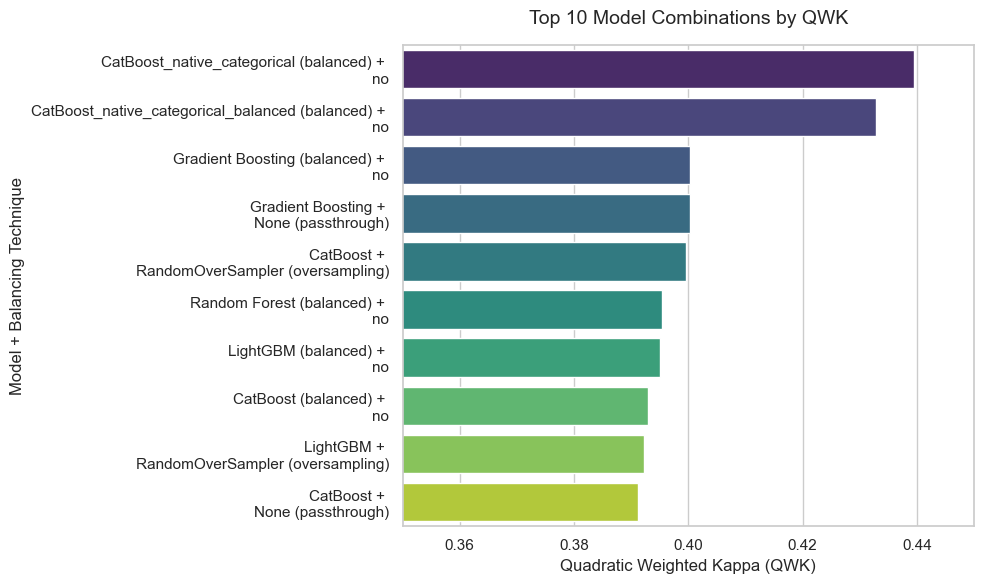

In [3]:
plt.figure(figsize=(10, 6))

# Extraer el Top 10 ordenado por QWK
top10 = df.sort_values('qwk_mean_test', ascending=False).head(10)

# Crear una etiqueta legible combinando modelo y técnica
top10['Label'] = top10['Model'].str.replace(' balanced', ' (balanced)') + " + \n" + top10['balancing_technique']

# Crear el gráfico de barras horizontales
sns.barplot(data=top10, x='qwk_mean_test', y='Label', palette='viridis')

# Formatear la gráfica
plt.title('Top 10 Model Combinations by QWK', fontsize=14, pad=15)
plt.xlabel('Quadratic Weighted Kappa (QWK)', fontsize=12)
plt.ylabel('Model + Balancing Technique', fontsize=12)
plt.xlim(0.35, 0.45) # Hacemos zoom en el rango de interés para que se vean las diferencias

plt.tight_layout()
plt.show()

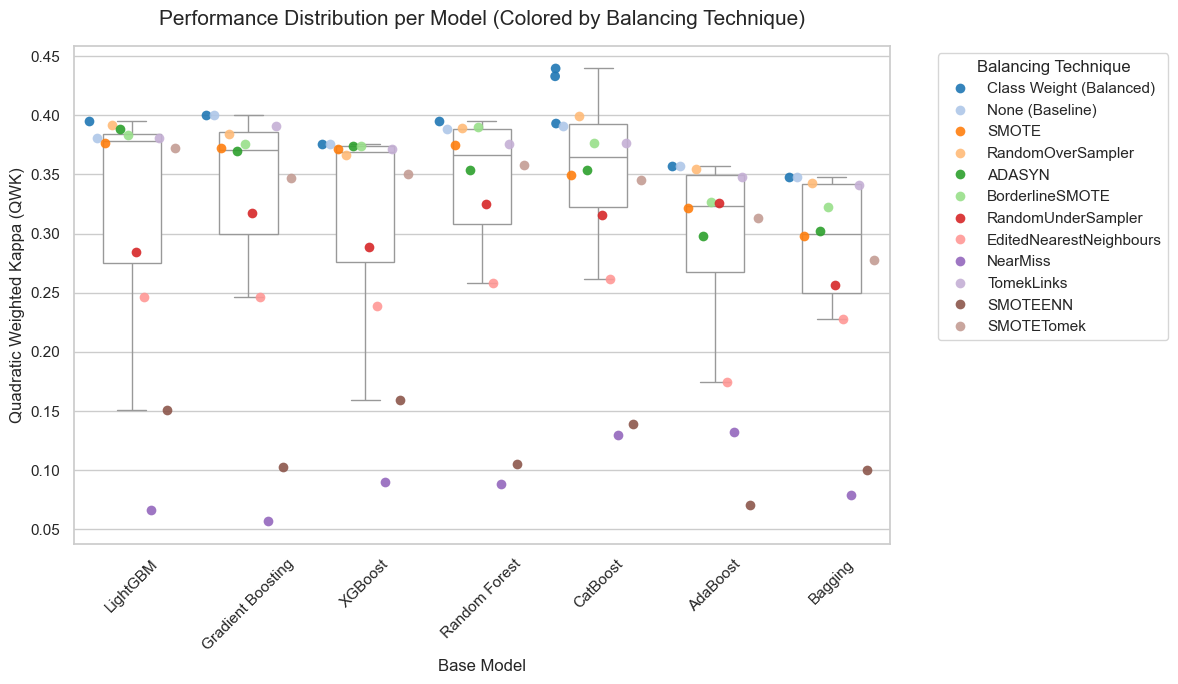

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# (Asegúrate de haber ejecutado antes la celda de limpieza de Base_Model)

# 1. Crear una función para extraer etiquetas más limpias para la leyenda
def clean_technique(row):
    tech = row['balancing_technique']
    model_name = row['Model']
    
    # Si no hay técnica explícita de remuestreo
    if pd.isna(tech) or tech == 'no' or tech == 'passthrough' or tech == 'None (passthrough)':
        if 'balanced' in model_name:
            return 'Class Weight (Balanced)'
        else:
            return 'None (Baseline)'
    else:
        # Simplificar nombres quitando el sufijo "(oversampling)", "(undersampling)", etc.
        # Por ejemplo, "SMOTE (oversampling)" pasa a ser "SMOTE"
        return tech.split(' ')[0]

# Aplicar la función al DataFrame
df['Technique_Label'] = df.apply(clean_technique, axis=1)

# Configurar el gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Ordenar los modelos en el eje X según su mediana de QWK
order = df.groupby('Base_Model')['qwk_mean_test'].median().sort_values(ascending=False).index

# 2. Dibujar el boxplot base (usamos color blanco para que no interfiera con los puntos)
sns.boxplot(data=df, x='Base_Model', y='qwk_mean_test', order=order, 
            color='white', width=0.5, showfliers=False)

# 3. Dibujar los puntos coloreados según la técnica
sns.stripplot(data=df, x='Base_Model', y='qwk_mean_test', order=order, 
              hue='Technique_Label', palette='tab20', size=7, alpha=0.9, dodge=True)

# Formatear la gráfica
plt.title('Performance Distribution per Model (Colored by Balancing Technique)', fontsize=15, pad=15)
plt.xlabel('Base Model', fontsize=12)
plt.ylabel('Quadratic Weighted Kappa (QWK)', fontsize=12)
plt.xticks(rotation=45)

# Mover la leyenda fuera para no tapar los datos
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Balancing Technique")

plt.tight_layout()
plt.show()

<Figure size 1600x600 with 0 Axes>

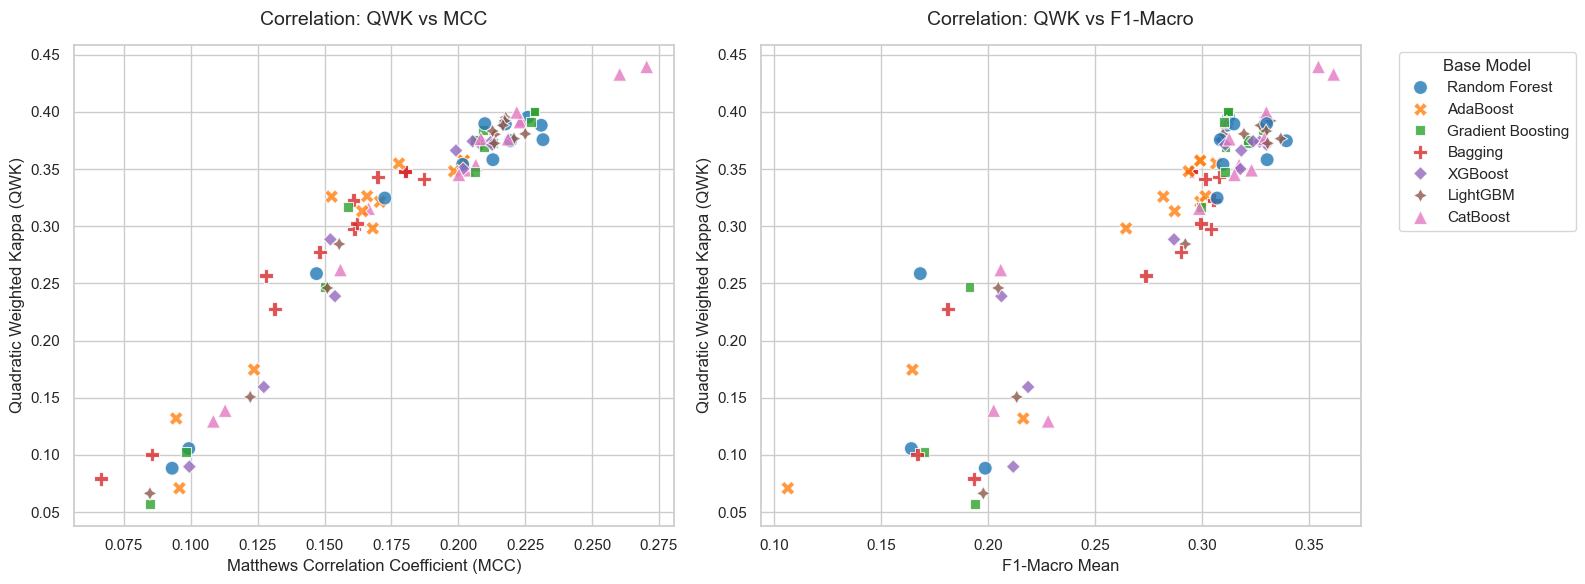

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# (Asegúrate de haber ejecutado antes la celda de preparación de datos 
# donde se define 'Base_Model' y se limpia el dataset)

plt.figure(figsize=(16, 6))

# Crear un lienzo con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico Izquierdo: QWK vs MCC ---
sns.scatterplot(data=df, x='mcc_mean_test', y='qwk_mean_test', 
                hue='Base_Model', style='Base_Model', palette='tab10', 
                s=100, alpha=0.8, ax=axes[0])
axes[0].set_title('Correlation: QWK vs MCC', fontsize=14, pad=15)
axes[0].set_xlabel('Matthews Correlation Coefficient (MCC)', fontsize=12)
axes[0].set_ylabel('Quadratic Weighted Kappa (QWK)', fontsize=12)
axes[0].get_legend().remove() # Quitamos la leyenda del primero para no duplicar

# --- Gráfico Derecho: QWK vs F1-Macro ---
sns.scatterplot(data=df, x='f1_mean_test', y='qwk_mean_test', 
                hue='Base_Model', style='Base_Model', palette='tab10', 
                s=100, alpha=0.8, ax=axes[1])
axes[1].set_title('Correlation: QWK vs F1-Macro', fontsize=14, pad=15)
axes[1].set_xlabel('F1-Macro Mean', fontsize=12)
axes[1].set_ylabel('Quadratic Weighted Kappa (QWK)', fontsize=12)

# Ponemos una única leyenda a la derecha del todo
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Base Model")

plt.tight_layout()
plt.show()